## Setup:

In [83]:
# ── All imports in one place ──────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_error
)

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    classification_report
)

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


print('Ready ✅')

Ready ✅


In [84]:
# Load dataset — each row is a student, each column is a feature
df = pd.read_csv('student_performance.csv')
print(f'Dataset: {df.shape[0]} students, {df.shape[1]} columns')
df.head(8)

Dataset: 200 students, 7 columns


,StudyHours,Attendance,PrevExamScore,SleepHours,FinalScore_Target_Regression,Pass_Target_Logistic,Grade_Target_MultiClass
0,3.7,82.1,37.2,4.8,48.6,0,F
1,9.5,54.2,93.2,5.4,86.4,1,A
2,7.3,58.1,65.4,4.9,75.8,1,B
3,6.0,94.9,87.9,4.4,82.7,1,B
4,1.6,80.3,52.4,4.6,55.4,0,C
5,1.6,50.5,92.7,6.3,53.9,0,F
6,0.6,55.1,57.2,5.0,38.5,0,F
7,8.7,83.2,30.8,5.8,68.2,1,C


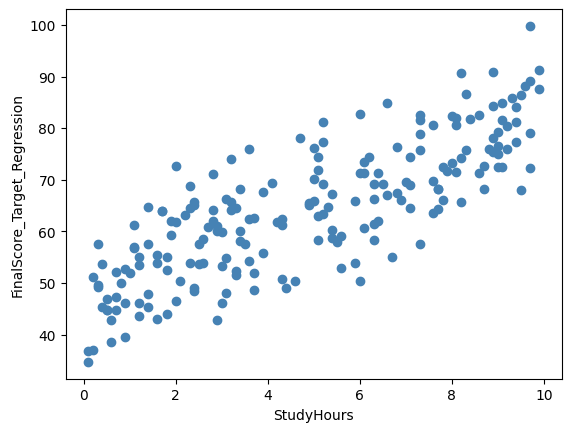

In [85]:
# Quick look at both features vs Salary
plt.scatter(df['StudyHours'], df['FinalScore_Target_Regression'], color='steelblue')
plt.xlabel('StudyHours')
plt.ylabel('FinalScore_Target_Regression')
plt.show()

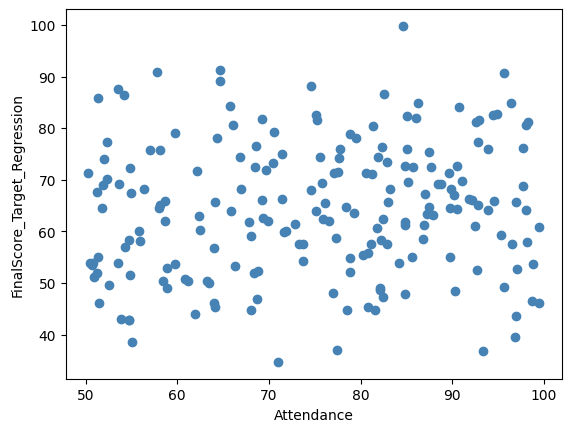

In [86]:
# Quick look at both features vs Salary
plt.scatter(df['Attendance'], df['FinalScore_Target_Regression'], color='steelblue')
plt.xlabel('Attendance')
plt.ylabel('FinalScore_Target_Regression')
plt.show()

## Linear Regrassion  :

In [87]:
from sklearn.model_selection import train_test_split
X = df[['StudyHours', 'Attendance', 'PrevExamScore', 'SleepHours']]
y = df['FinalScore_Target_Regression']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


print(f'Train: {len(X_train)} rows  |  Test: {len(X_test)} rows')

Train: 160 rows  |  Test: 40 rows


In [88]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"R²:   {r2:.3f}")

print("\nIntercept:", model.intercept_)
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:<16} {coef:.4f}")

RMSE: 3.579
MAE:  2.916
R²:   0.930

Intercept: 13.04076238143444
  StudyHours       3.5959
  Attendance       0.1597
  PrevExamScore    0.2999
  SleepHours       0.2676


In [89]:
def predict_score(study_hours, attendance_pct, prev_score, sleep_hours):
    new_student = pd.DataFrame([{
        'StudyHours': study_hours,
        'Attendance': attendance_pct,
        'PrevExamScore': prev_score,
        'SleepHours': sleep_hours
    }])

    predicted = model.predict(new_student)[0]
    return round(predicted, 2)

score = predict_score(
    study_hours=5,
    sleep_hours=7,
    attendance_pct=35,
    prev_score=90
)

print(f"Predicted final score: {score}")

Predicted final score: 65.47


## logistic Regression :

In [90]:
features = ['StudyHours', 'Attendance', 'PrevExamScore', 'SleepHours']
X_t = df[features]
y_t = df['Pass_Target_Logistic']

X_tr_t, X_te_t, y_tr_t, y_te_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

# Scale features — important for logistic regression
scaler = StandardScaler()
X_tr_t_scaled = scaler.fit_transform(X_tr_t)
X_te_t_scaled = scaler.transform(X_te_t)

In [91]:
log_model = LogisticRegression()
log_model.fit(X_tr_t_scaled, y_tr_t)

print('Coefficients:')
for feat, coef in zip(features, log_model.coef_[0]):
    print(f'  {feat:<8}: {coef:>7.3f}')
print(f'  Intercept: {log_model.intercept_[0]:.3f}')

Coefficients:
  StudyHours:   2.810
  Attendance:   0.699
  PrevExamScore:   1.803
  SleepHours:  -0.024
  Intercept: 1.338


In [92]:
y_pred_t = log_model.predict(X_te_t_scaled)

accuracy = accuracy_score(y_te_t, y_pred_t)
print(f'Accuracy: {accuracy:.4f}  ({accuracy*100:.1f}% of passengers correctly classified)')

Accuracy: 0.9750  (97.5% of passengers correctly classified)


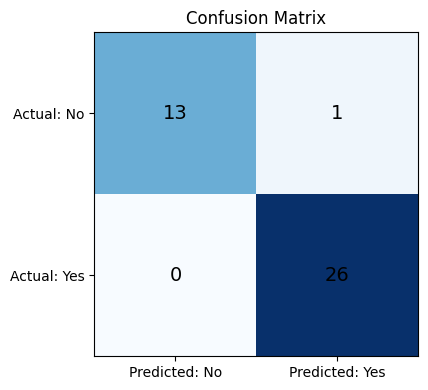

In [93]:
# Confusion matrix
cm = confusion_matrix(y_te_t, y_pred_t)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: No', 'Predicted: Yes'])
ax.set_yticklabels(['Actual: No', 'Actual: Yes'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', fontsize=14, color='black')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

In [94]:
# Predict probability for a new passenger
# 1st class, female, age 29, fare 80
new_Student = scaler.transform([[7, 65, 70, 7]])
prob = log_model.predict_proba(new_Student)[0][1]
print(f'success probability: {prob:.2%}')

success probability: 96.11%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## multi _ Class _ classification:

In [95]:
# How many students per grade?
df['Grade_Target_MultiClass'].value_counts()

,count
Grade_Target_MultiClass,
C,81
B,56
F,53
A,10


In [96]:
# Prepare features and target for multi-class
# Features (X) = what the model uses to make a prediction
# Target (y)   = what we want to predict

X = df[['StudyHours', 'Attendance', 'PrevExamScore', 'SleepHours']]
y = df['Grade_Target_MultiClass']   # multi-class target: A / B / C / Fail


# Split: 80% to train the model, 20% to test it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

Training samples : 160
Testing  samples : 40


In [97]:
# Train a Logistic Regression model on 4 classes
model = LogisticRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

print('Predictions for the first 10 test students:')
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': y_pred[:10]})
print(f'Actual: {y_test.values[:10]}')
print(f'Predicted: {y_pred[:10]}')


Predictions for the first 10 test students:
Actual: ['B' 'C' 'B' 'C' 'F' 'F' 'F' 'F' 'C' 'C']
Predicted: ['B' 'C' 'B' 'C' 'F' 'F' 'F' 'C' 'C' 'C']


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [98]:
# The model can also give a PROBABILITY for each class
# This is the softmax output — all probabilities sum to 1

proba = model.predict_proba(X_test)

print('Predicted class probabilities for the first 5 students:')
proba.round(2)[:5]

Predicted class probabilities for the first 5 students:


array([[0.  , 0.53, 0.44, 0.03],
       [0.  , 0.09, 0.65, 0.26],
       [0.1 , 0.54, 0.35, 0.01],
       [0.01, 0.46, 0.46, 0.08],
       [0.  , 0.04, 0.45, 0.51]])

In [99]:
# Cross-entropy loss — one line with sklearn
loss = log_loss(y_test, proba)
print(f'Cross-Entropy Loss: {loss:.4f}')
print()
print('Interpretation:')
print('  < 0.3  → model is very confident and mostly right')
print('  0.3–1  → decent, some uncertainty')
print('  > 1    → model is confused or overconfident in wrong answers')

Cross-Entropy Loss: 0.6608

Interpretation:
  < 0.3  → model is very confident and mostly right
  0.3–1  → decent, some uncertainty
  > 1    → model is confused or overconfident in wrong answers


### Confusion Matrix

Shows us **where** the model made mistakes — which classes it confused with each other.

- The **diagonal** = correct predictions ✅
- Everything **off-diagonal** = mistakes ❌

<Figure size 600x500 with 0 Axes>

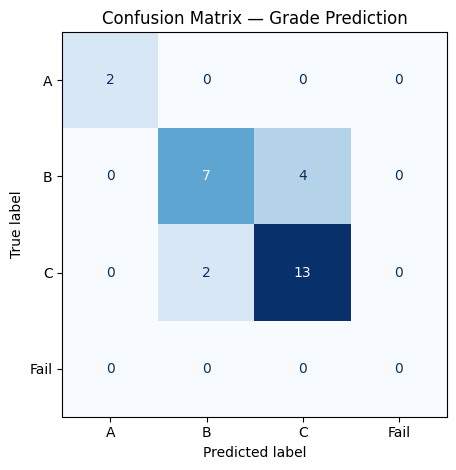

In [100]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['A', 'B', 'C', 'Fail'])

plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C', 'Fail'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Grade Prediction')
plt.tight_layout()
plt.show()

In [101]:
# Accuracy, Precision, Recall, F1 — all in one
print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['A', 'B', 'C', 'Fail']))

print('=== Individual Metrics ===')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2%}  — overall % correct')
print(f'Precision : {precision_score(y_test, y_pred, average="macro"):.2%}  — when it says a class, how often is it right?')
print(f'Recall    : {recall_score(y_test, y_pred, average="macro"):.2%}  — of the real class, how many did it catch?')
print(f'F1 Score  : {f1_score(y_test, y_pred, average="macro"):.2%}  — balance between precision & recall')

=== Classification Report ===
              precision    recall  f1-score   support

           A       1.00      1.00      1.00         2
           B       0.78      0.64      0.70        11
           C       0.72      0.81      0.76        16
        Fail       0.91      0.91      0.91        11

    accuracy                           0.80        40
   macro avg       0.85      0.84      0.84        40
weighted avg       0.80      0.80      0.80        40

=== Individual Metrics ===
Accuracy  : 80.00%  — overall % correct
Precision : 85.23%  — when it says a class, how often is it right?
Recall    : 83.95%  — of the real class, how many did it catch?
F1 Score  : 84.34%  — balance between precision & recall


## Decision Tree :

Accuracy: 0.600

Classification Report:
              precision    recall  f1-score   support

           A       1.00      0.50      0.67         2
           B       0.53      0.73      0.62        11
           C       0.54      0.44      0.48        16
           F       0.73      0.73      0.73        11

    accuracy                           0.60        40
   macro avg       0.70      0.60      0.62        40
weighted avg       0.61      0.60      0.60        40

Confusion Matrix (rows=actual, cols=predicted):
   A  B  C  F
A  1  1  0  0
B  0  8  3  0
C  0  6  7  3
F  0  0  3  8

--- Tree structure ---
|--- StudyHours <= 6.05
|   |--- PrevExamScore <= 71.90
|   |   |--- StudyHours <= 4.75
|   |   |   |--- PrevExamScore <= 52.05
|   |   |   |   |--- class: F
|   |   |   |--- PrevExamScore >  52.05
|   |   |   |   |--- class: F
|   |   |--- StudyHours >  4.75
|   |   |   |--- StudyHours <= 5.55
|   |   |   |   |--- class: C
|   |   |   |--- StudyHours >  5.55
|   |   |   |   |--- 

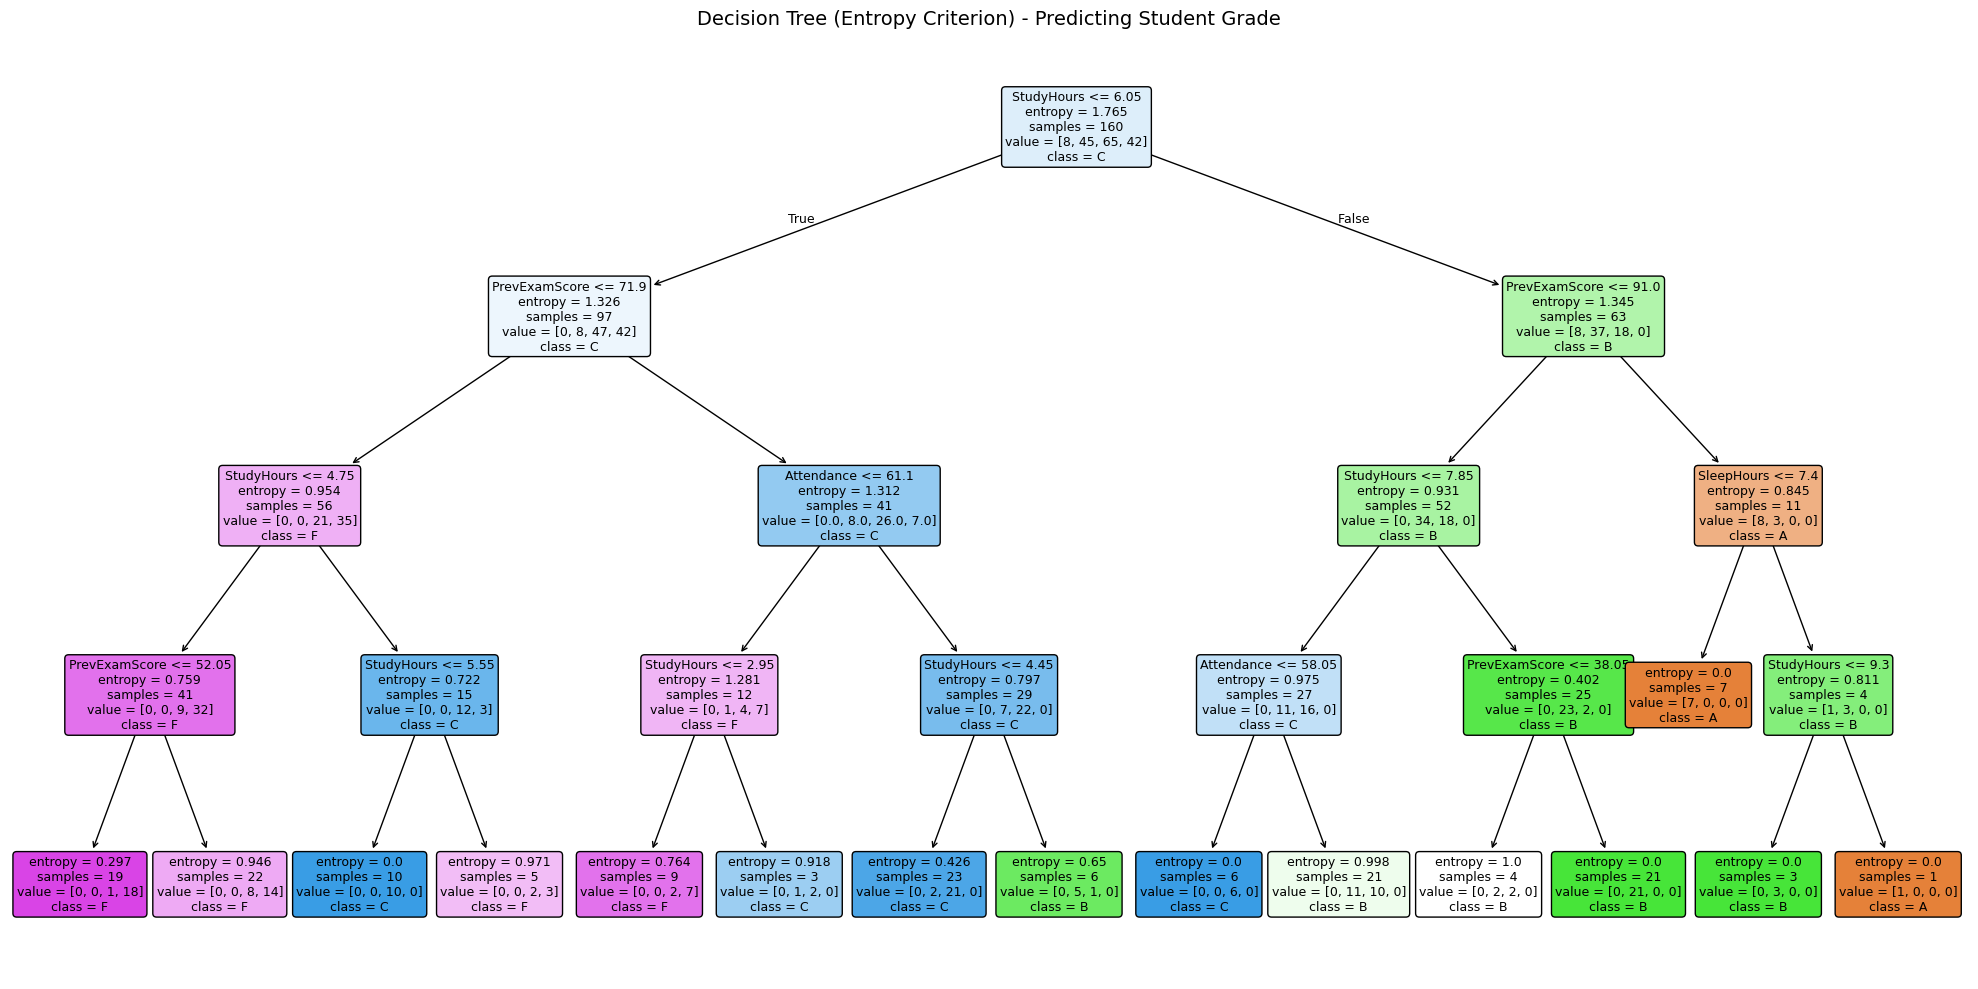

In [103]:
# ============================================================
# 1. تحميل البيانات
# ============================================================

df = pd.read_csv('student_performance.csv')

X = df[['StudyHours', 'Attendance', 'PrevExamScore', 'SleepHours']]
y = df['Grade_Target_MultiClass']   # multi-class target: A / B / C / Fail

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ============================================================
# 2. بناء Decision Tree باستخدام Entropy (Cross-Entropy criterion)
# ============================================================

tree = DecisionTreeClassifier(
    criterion='entropy',   # ده اللي بيستخدم Information Gain المبني على Entropy
    max_depth=4,
    random_state=42
)

tree.fit(X_train, y_train)


# ============================================================
# 3. التقييم
# ============================================================

y_pred = tree.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix (rows=actual, cols=predicted):")

labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

print(pd.DataFrame(cm, index=labels, columns=labels))


# ============================================================
# 4. عرض شجرة القرار كـ نص (يوضح كل split)
# ============================================================

print("\n--- Tree structure ---")
print(export_text(tree, feature_names=list(X.columns)))


# ============================================================
# 5. Feature Importance
# ============================================================

print("Feature Importance:")

for feat, imp in sorted(
    zip(X.columns, tree.feature_importances_),
    key=lambda x: -x[1]
):
    print(f"  {feat:<16} {imp:.4f}")


# ============================================================
# 6. حساب الـ Entropy الابتدائي يدويًا (زي ما الدكتور بيشرح)
# ============================================================

def entropy(y_series):
    probs = y_series.value_counts(normalize=True)
    return -np.sum(probs * np.log2(probs))


root_entropy = entropy(y_train)

print(f"\nRoot node entropy: {root_entropy:.4f} bits")


# ============================================================
# 7. رسم الشجرة
# ============================================================

plt.figure(figsize=(20, 10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=tree.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title(
    "Decision Tree (Entropy Criterion) - Predicting Student Grade",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    'decision_tree.png',
    dpi=150,
    bbox_inches='tight'
)